In [1]:
import numpy as np 
import pandas as pd 

from sklearn.preprocessing import MinMaxScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel

In [2]:
X_train = pd.read_csv("../Data/X_train.csv")
X_test = pd.read_csv("../Data/X_test.csv")

y_train = pd.read_csv("../Data/y_train.csv").squeeze()
y_test = pd.read_csv("../Data/y_test.csv").squeeze()

In [3]:
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

In [4]:
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

In [5]:
y_train_scaled = y_scaler.fit_transform(y_train.to_numpy().reshape(-1,1))
y_test_scaled = y_scaler.transform(y_test.to_numpy().reshape(-1,1))

In [6]:
kernel = (
    ConstantKernel(1.0, (1e-3, 1e3))
    * RBF(
        length_scale=np.ones(X_train.shape[1]),
        length_scale_bounds=(1e-2, 1e2)
    )
    + WhiteKernel(
        noise_level=1e-3,
        noise_level_bounds=(1e-6, 1e0)
    )
)

In [7]:
gp_model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=5,
    random_state=1000,
    normalize_y=False
)

In [8]:
gp_model.fit(X_train_scaled, y_train_scaled)

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP.If `None` is passed,the kernel `ConstantKernel() * RBF()` is used as default.Note thatthe kernel hyperparameters are optimized during fittingunless the bounds are marked as `""fixed""`or the argument `optimizer` is set to `None`.",1**2 * RBF(le...e_level=0.001)
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",5
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",1000
,kernel__k1,"1**2 * RBF(le..., 1, 1, 1, 1])"
,kernel__k2,WhiteKernel(noise_level=0.001)
,kernel__k1__k1,1**2
,kernel__k1__k2,"RBF(length_sc..., 1, 1, 1, 1])"
,kernel__k1__k1__constant_value,1.0
,kernel__k1__k1__constant_value_bounds,"(0.001, ...)"
,kernel__k1__k2__length_scale,"array([1., 1., 1., 1., 1.])"
,kernel__k1__k2__length_scale_bounds,"(0.01, ...)"


In [9]:
print(gp_model.kernel_)

0.358**2 * RBF(length_scale=[0.0611, 0.356, 0.376, 2.26, 0.159]) + WhiteKernel(noise_level=0.00165)


In [10]:
y_train_pred_scaled = gp_model.predict(X_train_scaled)

In [11]:
y_test_pred_scaled, y_test_std_scaled = gp_model.predict(
    X_test_scaled,
    return_std=True
)

In [12]:
y_train_pred = y_scaler.inverse_transform(
    y_train_pred_scaled.reshape(-1, 1)
).ravel()

y_test_pred = y_scaler.inverse_transform(
    y_test_pred_scaled.reshape(-1, 1)
).ravel()

In [13]:
y_test_std = y_test_std_scaled / y_scaler.scale_[0]

In [ ]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error
)
r2_train = r2_score(y_train,y_train_pred)
mae_train = mean_absolute_error(y_train,y_train_pred)
mse_train = mean_squared_error(y_train,y_train_pred)
rmse_train = root_mean_squared_error(y_train,y_train_pred)

r2_test = r2_score(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = root_mean_squared_error(y_test, y_test_pred)

print(f"R2:   {r2_test:.3f}")
print(f"MAE:  {mae_test:.3f} dB")
print(f"MSE:  {mse_test:.3f} dB2")
print(f"RMSE: {rmse_test:.3f} dB")

R²:   0.937
MAE:  1.224 dB
MSE:  3.102 dB²
RMSE: 1.761 dB


In [15]:
lower_95 = y_test_pred - 1.96 * y_test_std
upper_95 = y_test_pred + 1.96 * y_test_std

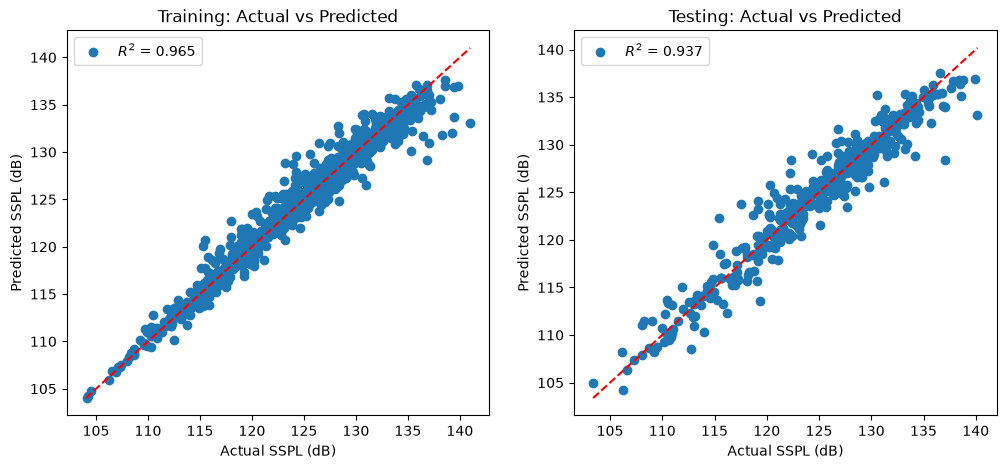

In [17]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(y_train, y_train_pred,label=f"$R^2$ = {r2_train:.3f}")
ax2.scatter(y_test, y_test_pred , label=f"$R^2$ = {r2_test:.3f}")

ax1.set_xlabel("Actual SSPL (dB)")
ax1.set_ylabel("Predicted SSPL (dB)")
ax1.set_title("Training: Actual vs Predicted")

low = min(y_train.min(), y_train_pred.min())
high = max(y_train.max(), y_train_pred.max())


ax1.plot([low, high], [low, high], linestyle="--", color="red")

ax2.set_xlabel("Actual SSPL (dB)")
ax2.set_ylabel("Predicted SSPL (dB)")
ax2.set_title("Testing: Actual vs Predicted")

low = min(y_test.min(), y_test_pred.min())
high = max(y_test.max(), y_test_pred.max())

ax2.plot([low, high], [low, high], linestyle="--", color="red")

ax1.legend()
ax2.legend()

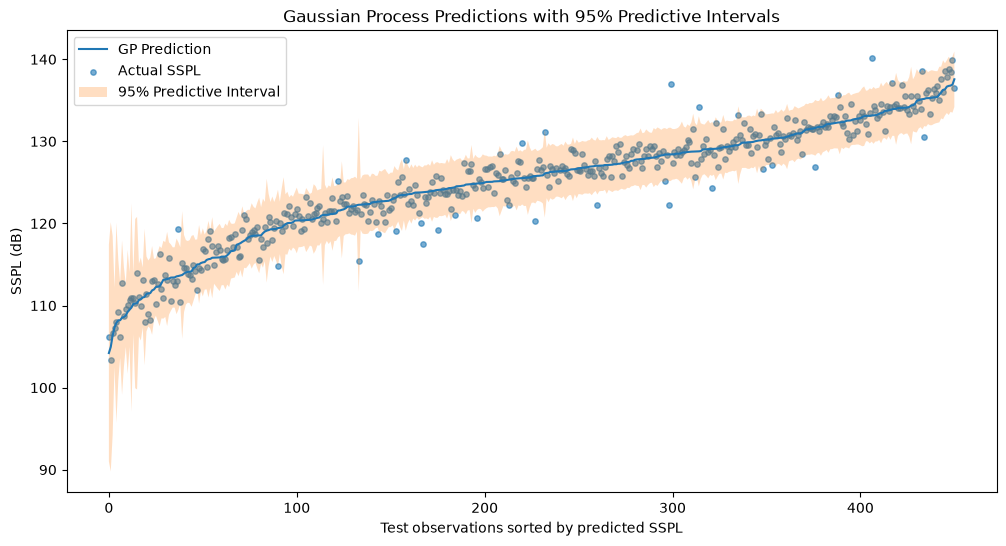

In [18]:
order = np.argsort(y_test_pred)

pred_sorted = y_test_pred[order]
std_sorted = y_test_std[order]
actual_sorted = y_test.to_numpy()[order]

lower_sorted = pred_sorted - 1.96 * std_sorted
upper_sorted = pred_sorted + 1.96 * std_sorted

x = np.arange(len(pred_sorted))

plt.figure(figsize=(12, 6))

plt.plot(
    x,
    pred_sorted,
    label="GP Prediction"
)

plt.scatter(
    x,
    actual_sorted,
    s=15,
    alpha=0.6,
    label="Actual SSPL"
)

plt.fill_between(
    x,
    lower_sorted,
    upper_sorted,
    alpha=0.25,
    label="95% Predictive Interval"
)

plt.xlabel("Test observations sorted by predicted SSPL")
plt.ylabel("SSPL (dB)")
plt.title("Gaussian Process Predictions with 95% Predictive Intervals")
plt.legend()
plt.show()

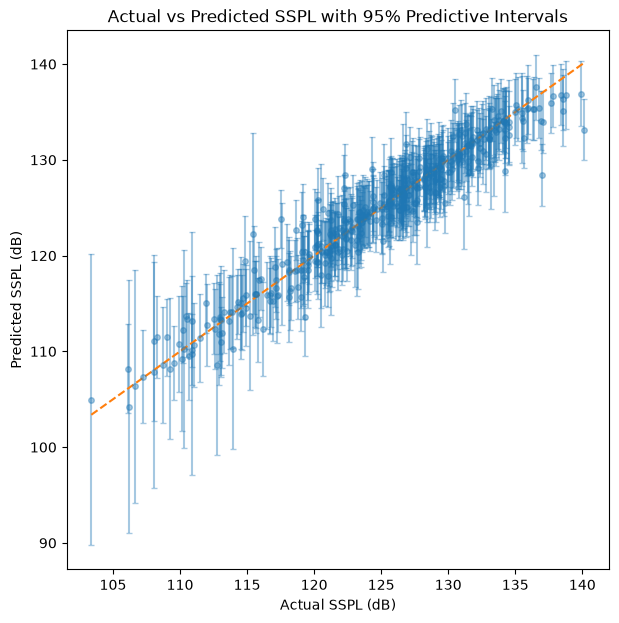

In [19]:
plt.figure(figsize=(7, 7))

plt.errorbar(
    y_test,
    y_test_pred,
    yerr=1.96 * y_test_std,
    fmt="o",
    alpha=0.4,
    markersize=4,
    capsize=2
)

low = min(y_test.min(), y_test_pred.min())
high = max(y_test.max(), y_test_pred.max())

plt.plot(
    [low, high],
    [low, high],
    "--"
)

plt.xlabel("Actual SSPL (dB)")
plt.ylabel("Predicted SSPL (dB)")
plt.title("Actual vs Predicted SSPL with 95% Predictive Intervals")

plt.show()

In [20]:
coverage_95 = np.mean(
    (y_test.to_numpy() >= lower_95) &
    (y_test.to_numpy() <= upper_95)
)

print(f"95% interval coverage: {coverage_95:.3f}")

95% interval coverage: 0.949


In [21]:
from scipy.stats import norm

confidence_levels = np.array([
    0.50,
    0.68,
    0.80,
    0.90,
    0.95,
    0.99
])

empirical_coverage = []

for confidence in confidence_levels:

    z = norm.ppf((1 + confidence) / 2)

    lower = y_test_pred - z * y_test_std
    upper = y_test_pred + z * y_test_std

    coverage = np.mean(
        (y_test.to_numpy() >= lower) &
        (y_test.to_numpy() <= upper)
    )

    empirical_coverage.append(coverage)

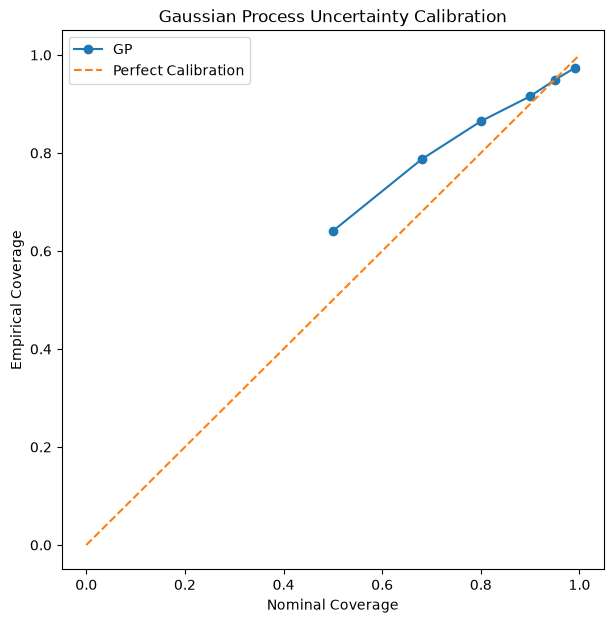

In [22]:
plt.figure(figsize=(7, 7))

plt.plot(
    confidence_levels,
    empirical_coverage,
    marker="o",
    label="GP"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Perfect Calibration"
)

plt.xlabel("Nominal Coverage")
plt.ylabel("Empirical Coverage")
plt.title("Gaussian Process Uncertainty Calibration")

plt.legend()
plt.show()

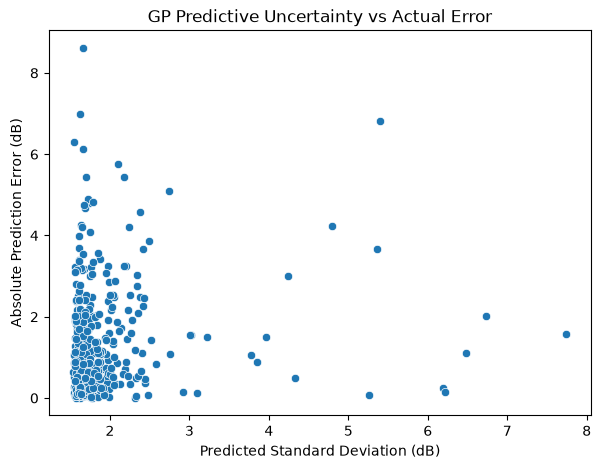

In [23]:
import seaborn as sns
absolute_error = np.abs(
    y_test.to_numpy() - y_test_pred
)

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=y_test_std,
    y=absolute_error
)

plt.xlabel("Predicted Standard Deviation (dB)")
plt.ylabel("Absolute Prediction Error (dB)")
plt.title("GP Predictive Uncertainty vs Actual Error")

plt.show()

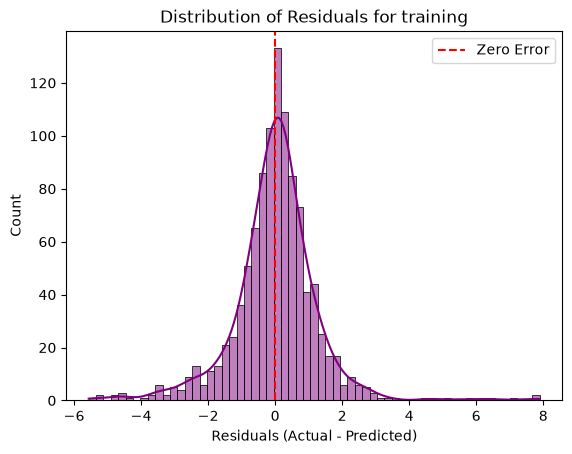

In [24]:
import seaborn as sns 
train_residuals = y_train - y_train_pred
sns.histplot(train_residuals,kde=True,color="purple")
plt.axvline(x=0, color="red", linestyle="--", label="Zero Error") # reference line
plt.title("Distribution of Residuals for training")
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Count")
plt.legend()
plt.show()

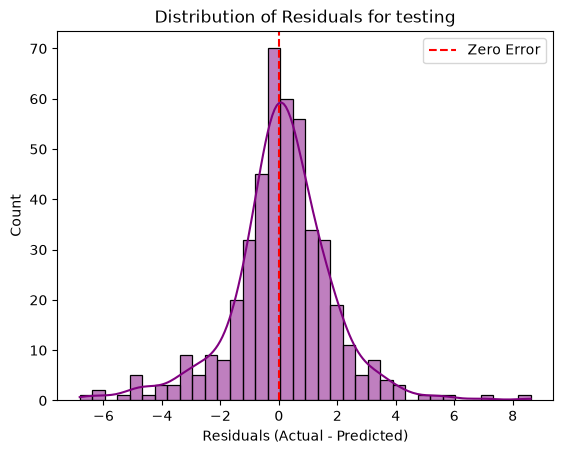

In [25]:
import seaborn as sns 
test_residuals = y_test - y_test_pred
sns.histplot(test_residuals,kde=True,color="purple")
plt.axvline(x=0, color="red", linestyle="--", label="Zero Error") # reference line
plt.title("Distribution of Residuals for testing")
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Count")
plt.legend()
plt.show()

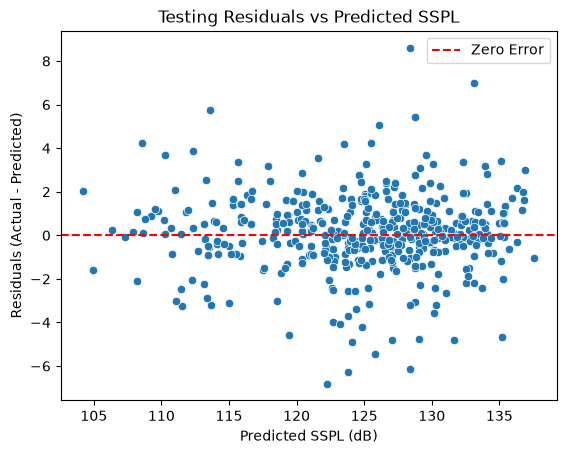

In [26]:
test_residuals = y_test - y_test_pred

sns.scatterplot(
    x=y_test_pred,
    y=test_residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    label="Zero Error"
)

plt.title("Testing Residuals vs Predicted SSPL")
plt.xlabel("Predicted SSPL (dB)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.legend()
plt.show()

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.model_selection import cross_validate

gp_pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("gp", GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=5,
        random_state=1000,
        normalize_y=False
    ))
])

gp_cv_model = TransformedTargetRegressor(
    regressor=gp_pipeline,
    transformer=MinMaxScaler()
)

scores = cross_validate(
    gp_cv_model,
    X_train,
    y_train,
    cv=5,
    scoring=(
        "r2",
        "neg_mean_absolute_error",
        "neg_mean_squared_error",
        "neg_root_mean_squared_error"
    ),
    return_train_score=True
)

In [28]:
cv_results = pd.DataFrame({
    "R2": scores["test_r2"],
    "MAE": -scores["test_neg_mean_absolute_error"],
    "MSE": -scores["test_neg_mean_squared_error"],
    "RMSE": -scores["test_neg_root_mean_squared_error"]
})

cv_results.index = [
    "Fold 1",
    "Fold 2",
    "Fold 3",
    "Fold 4",
    "Fold 5"
]

cv_results

,R2,MAE,MSE,RMSE
Fold 1,0.936205,1.193360,3.023303,1.738765
Fold 2,0.877697,1.492945,4.926612,2.219597
Fold 3,0.916228,1.358961,4.028700,2.007162
Fold 4,0.892427,1.558546,5.143358,2.267897
Fold 5,0.940866,1.194009,2.824903,1.680745


In [29]:
cv_summary = pd.DataFrame({
    "Mean": cv_results.mean(),
    "Std": cv_results.std()
})

cv_summary

,Mean,Std
R2,0.912685,0.027361
MAE,1.359564,0.167643
MSE,3.989375,1.060769
RMSE,1.982833,0.268672
